<a href="https://colab.research.google.com/github/Aswini-J/Exp3-Sobel-edge-detection-filter-using-CUDA-to-enhance-the-performance-of-image-processing-tasks./blob/main/Sobel_edge_detection_image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install git+https://github.com/andreinechaev/nvcc4jupyter.git
%load_ext nvcc4jupyter

  Cloning https://github.com/andreinechaev/nvcc4jupyter.git to /tmp/pip-req-build-w12o7suz
  Running command git clone --filter=blob:none --quiet https://github.com/andreinechaev/nvcc4jupyter.git /tmp/pip-req-build-w12o7suz
  Resolved https://github.com/andreinechaev/nvcc4jupyter.git to commit 28f872a2f99a1b201bcd0db14fdbc5a496b9bfd7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nvcc4jupyter: filename=nvcc4jupyter-1.2.1-py3-none-any.whl size=10741 sha256=90a829d54142cdbaf5703d6409de30ec0002408286cfbcd108dfdd84cf0ee4fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-61q0wbje/wheels/7d/b9/66/459b9938664e6a93d1a85323ec52f7e51cd7265d253410a7d8
Successfully built nvcc4jupyter
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpbrmb7o7u".


In [2]:
!nvcc --version


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [3]:
%load_ext nvcc4jupyter

The nvcc4jupyter extension is already loaded. To reload it, use:
  %reload_ext nvcc4jupyter


In [4]:
from pathlib import Path

file_path = Path('/absolute/path/to/images.jpeg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")


File does not exist!


In [5]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: /content


In [6]:
from google.colab import files
uploaded = files.upload()

Saving RONALDO prime dönem foto.jpg to RONALDO prime dönem foto.jpg


In [11]:
from pathlib import Path

# Assuming the file is in the same directory as the notebook
file_path = Path('/content/RONALDO prime dönem foto.jpg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")


File exists!


In [12]:
pwd


'/content'

In [13]:
ls /content/images.jpeg

ls: cannot access '/content/images.jpeg': No such file or directory


In [15]:
#ls -l /content/images.jpeg
import cv2
image = cv2.imread('/content/RONALDO prime dönem foto.jpg')
if image is None:
    print("Error: Image not found or unable to read the image.")
else:
    print("Image read successfully.")


Image read successfully.


In [24]:
%%writefile sobelEdgeDetectionFilter.cu

#include <iostream>
#include <opencv2/opencv.hpp>
#include <cuda_runtime.h>
#include <math.h>
#include <stdio.h>

using namespace cv;

__global__ void sobelFilter(unsigned char *srcImage, unsigned char *dstImage,
                            unsigned int width, unsigned int height) {

    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    // Boundary check
    if (x > 0 && x < width - 1 && y > 0 && y < height - 1) {

        int gx = 0;
        int gy = 0;

        // Sobel X kernel
        gx = -srcImage[(y - 1) * width + (x - 1)]
             -2 * srcImage[y * width + (x - 1)]
             -srcImage[(y + 1) * width + (x - 1)]
             +srcImage[(y - 1) * width + (x + 1)]
             +2 * srcImage[y * width + (x + 1)]
             +srcImage[(y + 1) * width + (x + 1)];

        // Sobel Y kernel
        gy = -srcImage[(y - 1) * width + (x - 1)]
             -2 * srcImage[(y - 1) * width + x]
             -srcImage[(y - 1) * width + (x + 1)]
             +srcImage[(y + 1) * width + (x - 1)]
             +2 * srcImage[(y + 1) * width + x]
             +srcImage[(y + 1) * width + (x + 1)];

        int magnitude = sqrtf((gx * gx) + (gy * gy));

        // Clamp value between 0 and 255
        if (magnitude > 255)
            magnitude = 255;

        dstImage[y * width + x] = (unsigned char)magnitude;
    }
}

void checkCudaErrors(cudaError_t r) {
    if (r != cudaSuccess) {
        fprintf(stderr, "CUDA Error: %s\n", cudaGetErrorString(r));
        exit(EXIT_FAILURE);
    }
}

int main() {

    // Read input image in grayscale
    Mat image = imread("/content/RONALDO prime dönem foto.jpg", IMREAD_GRAYSCALE);

    if (image.empty()) {
        printf("Error: Image not found.\n");
        return -1;
    }

    int width = image.cols;
    int height = image.rows;

    size_t imageSize = width * height * sizeof(unsigned char);

    // Allocate host memory
    unsigned char *h_outputImage = (unsigned char *)malloc(imageSize);

    // Allocate device memory
    unsigned char *d_inputImage, *d_outputImage;

    checkCudaErrors(cudaMalloc(&d_inputImage, imageSize));
    checkCudaErrors(cudaMalloc(&d_outputImage, imageSize));

    // Copy image to GPU
    checkCudaErrors(cudaMemcpy(d_inputImage, image.data,
                               imageSize, cudaMemcpyHostToDevice));

    // CUDA events for timing
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // Block and grid size
    dim3 blockSize(16, 16);
    dim3 gridSize((width + 15) / 16, (height + 15) / 16);

    // Start timing
    cudaEventRecord(start);

    // Launch kernel
    sobelFilter<<<gridSize, blockSize>>>(d_inputImage,
                                         d_outputImage,
                                         width,
                                         height);

    cudaEventRecord(stop);

    // Wait for GPU
    cudaEventSynchronize(stop);

    // Measure time
    float milliseconds = 0;
    cudaEventElapsedTime(&milliseconds, start, stop);

    // Copy result back
    checkCudaErrors(cudaMemcpy(h_outputImage,
                               d_outputImage,
                               imageSize,
                               cudaMemcpyDeviceToHost));

    // Save output image
    Mat outputImage(height, width, CV_8UC1, h_outputImage);

    imwrite("output_sobel.jpeg", outputImage);

    // Free memory
    free(h_outputImage);

    cudaFree(d_inputImage);
    cudaFree(d_outputImage);

    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    printf("Total time taken: %f milliseconds\n", milliseconds);

    return 0;
}

Overwriting sobelEdgeDetectionFilter.cu


In [28]:
!nvcc -o sobelEdgeDetectionFilter sobelEdgeDetectionFilter.cu -I/usr/include/opencv4 -L/usr/lib/x86_64-linux-gnu -lopencv_core -lopencv_imgproc -lopencv_highgui -lopencv_imgcodecs

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::buildMaps" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::warp" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

/usr/include/opencv4/opencv2/stitching/detail/blenders.hpp(100): warning #611-D: overloaded virtual function "cv::detail::Blender::prepare" is only partially overridden in class "cv::detail::FeatherBlender"
  clas

In [26]:
!apt-get update
!apt-get install -y libopencv-dev

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.2 MB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,945 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,

In [27]:
!nvcc -o sobelEdgeDetectionFilter sobelEdgeDetectionFilter.cu `pkg-config --cflags --libs opencv`

Package opencv was not found in the pkg-config search path.
Perhaps you should add the directory containing `opencv.pc'
to the PKG_CONFIG_PATH environment variable
Package 'opencv', required by 'virtual:world', not found
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
sobelEdgeDetectionFilter.cu:3:10: fatal error: opencv2/opencv.hpp: No such file or directory
    3 | #include <opencv2/opencv.hpp>
      |          ^~~~~~~~~~~~~~~~~~~~
compilation terminated.


In [29]:
!./sobelEdgeDetectionFilter

Total time taken: 105.912094 milliseconds


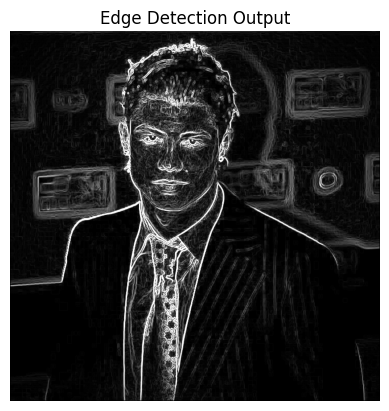

In [30]:
import cv2
from matplotlib import pyplot as plt

# Read and display the output image
output_image_path = '/content/output_sobel.jpeg'
output_image = cv2.imread(output_image_path, cv2.IMREAD_GRAYSCALE)  # Use IMREAD_GRAYSCALE if it's a single-channel image

if output_image is None:
    print(f"Error: The image file '{output_image_path}' could not be loaded. Please ensure the Sobel filter CUDA code ran successfully and generated the output image.")
else:
    # Display the image
    plt.imshow(output_image, cmap='gray')
    plt.title('Edge Detection Output')
    plt.axis('off')  # Hide the axes
    plt.show()